<a href="https://colab.research.google.com/github/Karimhossion/Drowsiness-Detection/blob/main/Project/Drowsiness_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/Drowsines_Dataset/Drowsines_Dataset.zip -d /content/data

Streaming output truncated to the last 5000 lines.
  inflating: /content/data/open_eye/s0024_00466_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00467_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00468_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00469_0_1_1_2_0_01.png  
  inflating: /content/data/open_eye/s0024_00470_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00471_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00472_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00473_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00474_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00475_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00476_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00477_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00478_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00479_0_1_1_0_0_01.png  
  inflating

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Dense,
    GlobalAveragePooling2D,
    Dropout,
    InputLayer,
    Flatten
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image_dataset_from_directory

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_curve
)

from tqdm import tqdm
import seaborn as sns

In [ ]:
BATCH_SIZE = 32
IMAGE_SIZE = 24
CHANNELS = 3
EPOCHS = 5
PATH = '/content/data/'

In [ ]:
train_ds = image_dataset_from_directory(
    PATH,
    seed = 42,
    shuffle = True,
    image_size = (IMAGE_SIZE , IMAGE_SIZE),
    batch_size = BATCH_SIZE,
    validation_split = 0.2,
    subset = 'training'

)

val_test_ds = image_dataset_from_directory(
    PATH,
    seed = 42,
    shuffle = True,
    image_size = (IMAGE_SIZE , IMAGE_SIZE),
    batch_size = BATCH_SIZE,
    validation_split = 0.2,
    subset = 'validation'

)


Found 48000 files belonging to 2 classes.
Using 38400 files for training.
Found 48000 files belonging to 2 classes.
Using 9600 files for validation.


In [ ]:
val_test_size = val_test_ds.cardinality().numpy()


val_size = val_test_size // 2

val_ds = val_test_ds.take(val_size)
test_ds = val_test_ds.skip(val_size)


In [ ]:
class_names = train_ds.class_names
class_names

['closed_eye', 'open_eye']

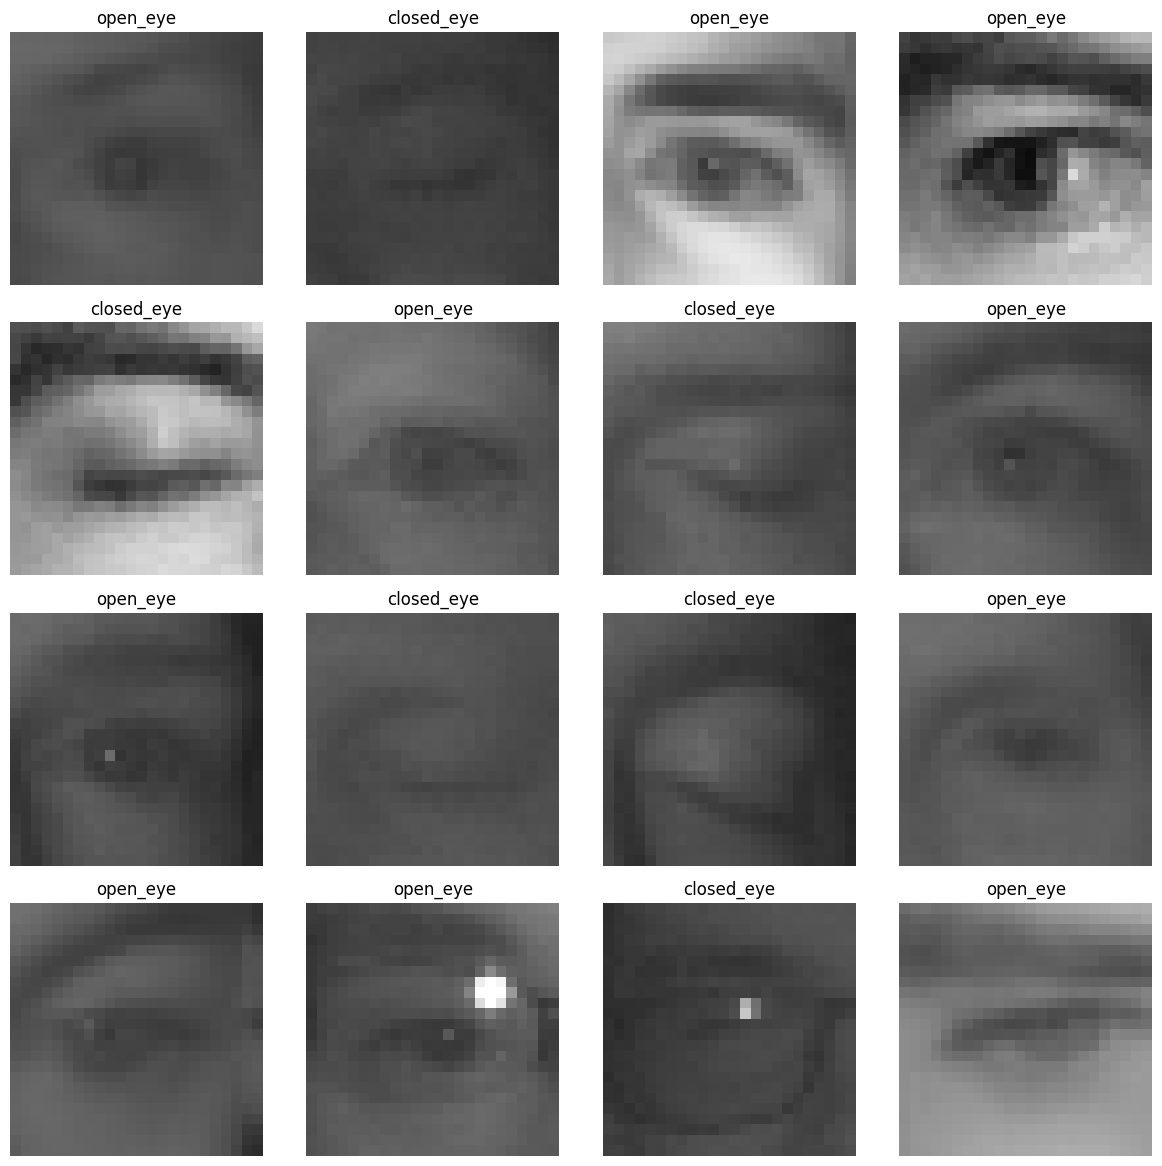

In [ ]:
plt.figure(figsize=(12, 12))
for batch_images, batch_labels in train_ds.take(1):
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(batch_images[i].numpy().astype("uint8"))
        plt.title(class_names[batch_labels[i]])
        plt.tight_layout()
        plt.axis("off")


In [ ]:
resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  layers.Rescaling(1./255),
])

In [ ]:
data_augmentation = tf.keras.Sequential([
  layers.RandomRotation(0.2),
  layers.RandomFlip(seed = 42)
])

In [ ]:
train_data = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = len(class_names)
inputs = Input(shape=input_shape)

base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_tensor=inputs,
    pooling='avg'
)

base_model.trainable = False
x = base_model.output
x = Dense(units=128, activation='relu')(x)
outputs = Dense(n_classes, activation='softmax')(x)
model = Model(inputs=inputs, outputs=outputs)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

In [ ]:
callback = [
    tf.keras.callbacks.ModelCheckpoint(filepath='model.keras', monitor="val_accuracy")
]

In [ ]:
history = model.fit(
    train_data,
    batch_size = BATCH_SIZE,
    validation_data = val_ds,
    verbose = 1,
    epochs = EPOCHS,
    callbacks = callback
)

Epoch 1/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - accuracy: 0.8791 - loss: 0.2936 - val_accuracy: 0.9398 - val_loss: 0.1585
Epoch 2/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.9380 - loss: 0.1566 - val_accuracy: 0.9548 - val_loss: 0.1280
Epoch 3/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.9504 - loss: 0.1338 - val_accuracy: 0.9548 - val_loss: 0.1248
Epoch 4/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9509 - loss: 0.1310 - val_accuracy: 0.9515 - val_loss: 0.1258
Epoch 5/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.9543 - loss: 0.1223 - val_accuracy: 0.9592 - val_loss: 0.1093


In [ ]:
model = load_model('model.keras')

In [ ]:
model.save('models/eyes.h5', overwrite=True)

In [ ]:
all_predictions = []
all_labels = []
for images, labels in tqdm(test_ds):
    predictions = model.predict(images, verbose = 0)
    predicted_classes = np.argmax(predictions, axis=1)
    all_predictions.extend(predicted_classes)
    all_labels.extend(labels.numpy())

100%|██████████| 150/150 [00:20<00:00,  7.33it/s]


In [ ]:
accuracy = accuracy_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')
precision = precision_score(all_labels, all_predictions, average='weighted')

print("Accuracy: ", accuracy)
print("F1 Score: ", f1)
print("Recall: ", recall)
print("Precision: ", precision)

Accuracy:  0.9541666666666667
F1 Score:  0.9541564122411091
Recall:  0.9541666666666667
Precision:  0.9543215987148576


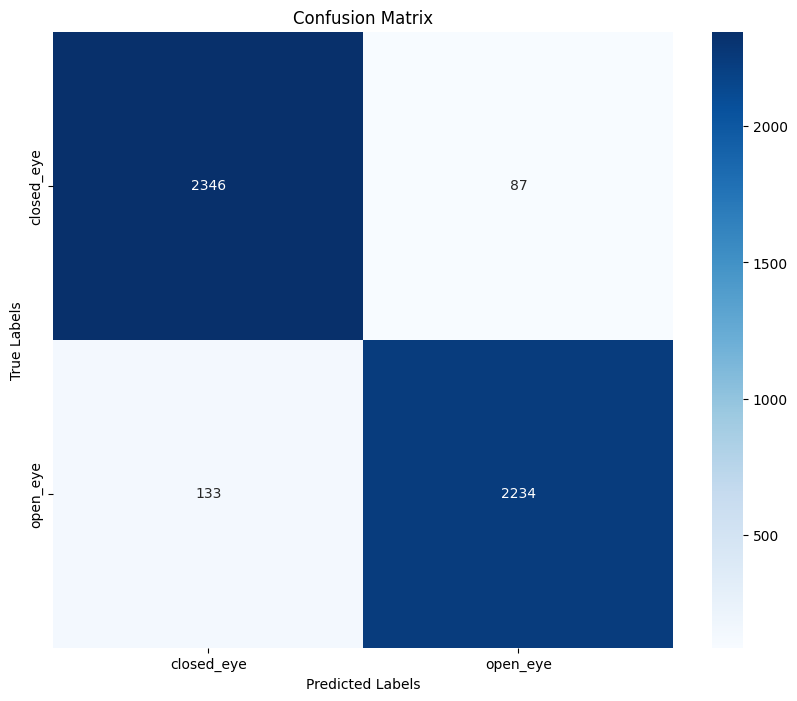

In [ ]:
conf_matrix = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.savefig('Confusion Matrix.png', dpi = 300)
plt.show()


In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

from scipy.ndimage import gaussian_filter1d

sacc = gaussian_filter1d(acc, sigma=2)
sval_acc = gaussian_filter1d(val_acc, sigma=2)

sloss = gaussian_filter1d(loss, sigma=2)
sval_loss = gaussian_filter1d(val_loss, sigma=2)

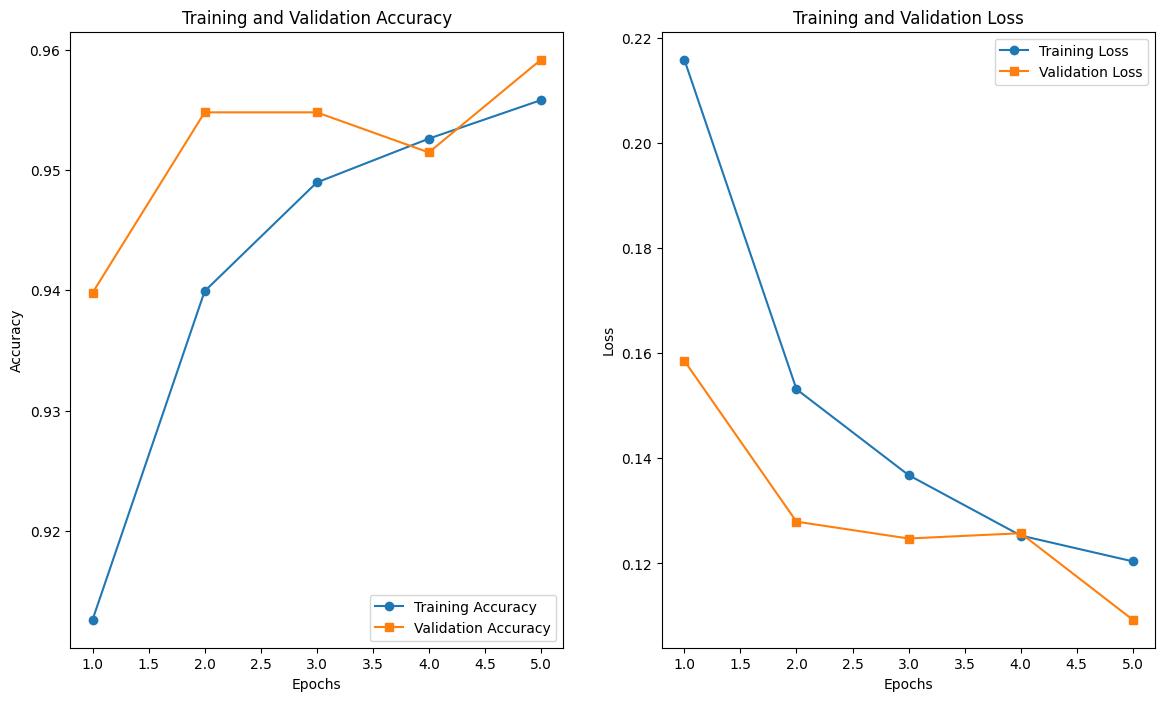

In [ ]:
plt.figure(figsize=(14, 8))

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), acc[:EPOCHS], marker='o', label='Training Accuracy')
plt.plot(range(1, EPOCHS + 1), val_acc[:EPOCHS], marker='s', label='Validation Accuracy')
plt.legend(loc='lower right')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title('Training and Validation Accuracy')

# Plot Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), loss[:EPOCHS], marker='o', label='Training Loss')
plt.plot(range(1, EPOCHS + 1), val_loss[:EPOCHS], marker='s', label='Validation Loss')
plt.legend(loc='upper right')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title('Training and Validation Loss')

# Save and Show the Plots
plt.savefig('curves.png', dpi=300)
plt.show()

In [ ]:
def predict(model, image):
    img_array = tf.keras.preprocessing.image.img_to_array(image.numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array, verbose = 0)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

<Figure size 640x480 with 0 Axes>

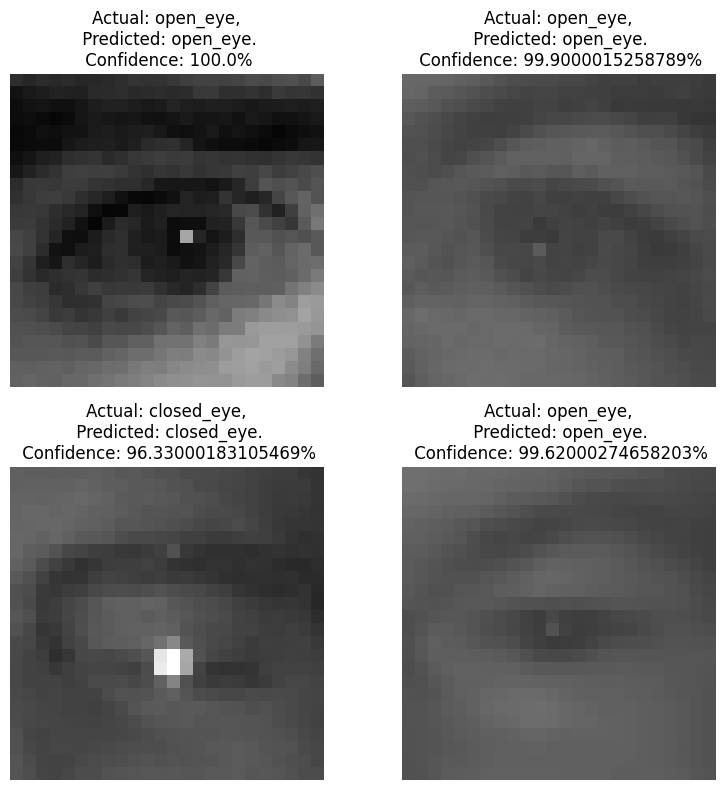

In [ ]:
plt.clf()
plt.figure(figsize=(8, 8))
for images, labels in test_ds.take(6):
    for i in range(4):
        ax = plt.subplot(2, 2, i + 1)
        if i < len(images):
            ax.imshow(images[i].numpy().astype("uint8"))

            predicted_class, confidence = predict(model, images[i])
            actual_class = class_names[labels[i]]

            ax.set_title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
            ax.axis("off")
plt.tight_layout()
plt.show()
